<a href="https://colab.research.google.com/github/Naylet92/Estudio_ambiental/blob/main/San%20Gabriel/SGB_clasificacion_ANN_2020_ver1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Prefijo del área
PREFIJO     = 'SGB'
# Nombre del área
NOMBRE      = 'San_Gabriel'

# Carpeta local donde se guardaran los .npy y .json de salida
#RUTA_DATOS ='/content/drive/MyDrive/ANP/Landsat/SVerde_Landsat/SVD_tif-2000/Nympy2000'
RUTA_DATOS = '/content/drive/MyDrive/Colab Data NDC 2020/Numpy'

YEAR        = 2020

reference_file_names = [
    f"{PREFIJO}_{YEAR}_ref_CP.npy",
    f"{PREFIJO}_{YEAR}_ref_EC.npy",
    f"{PREFIJO}_{YEAR}_ref_DW.npy"
]

imagery_file_names = [
    f"{PREFIJO}_{YEAR}_L8_PCA6_rs.npy",
    f"{PREFIJO}_{YEAR}_L8_PCA6_ss.npy"
]



In [2]:
import os
import numpy as np
import math
import rasterio
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, cohen_kappa_score
from google.colab import drive

drive.mount('/content/drive')
random.seed(2)

Mounted at /content/drive


## Presentar datos

--- Procesando Archivos de Referencia ---

Procesando archivo: SGB_2020_ref_CP.npy
  Forma: (1, 464, 486)
  Número de elementos: 225504

Procesando archivo: SGB_2020_ref_EC.npy
  Forma: (1, 464, 486)
  Número de elementos: 225504

Procesando archivo: SGB_2020_ref_DW.npy
  Forma: (1, 464, 486)
  Número de elementos: 225504


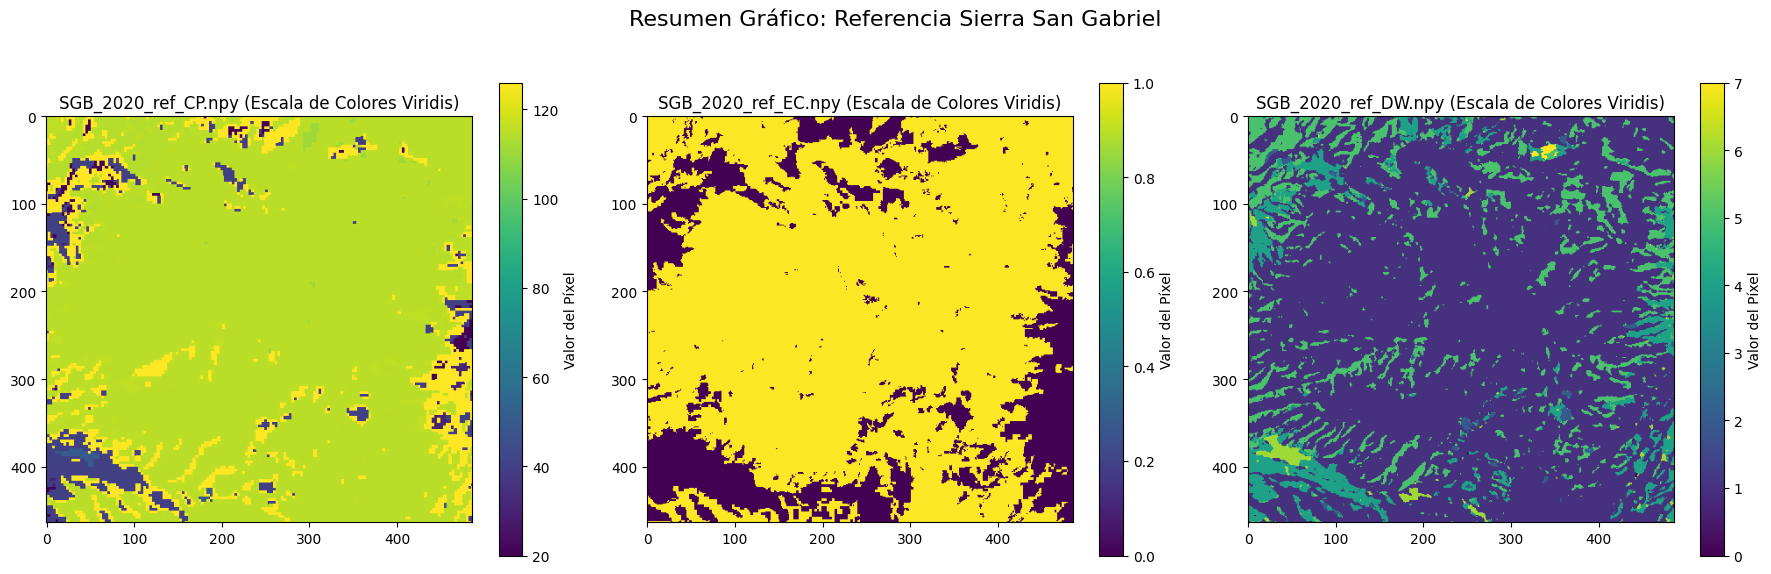


--- Procesando Archivos de Imágenes ---

Procesando archivo: SGB_2020_L8_PCA6_rs.npy
  Forma: (6, 464, 486)
  Número de elementos: 1353024

Procesando archivo: SGB_2020_L8_PCA6_ss.npy
  Forma: (6, 464, 486)
  Número de elementos: 1353024


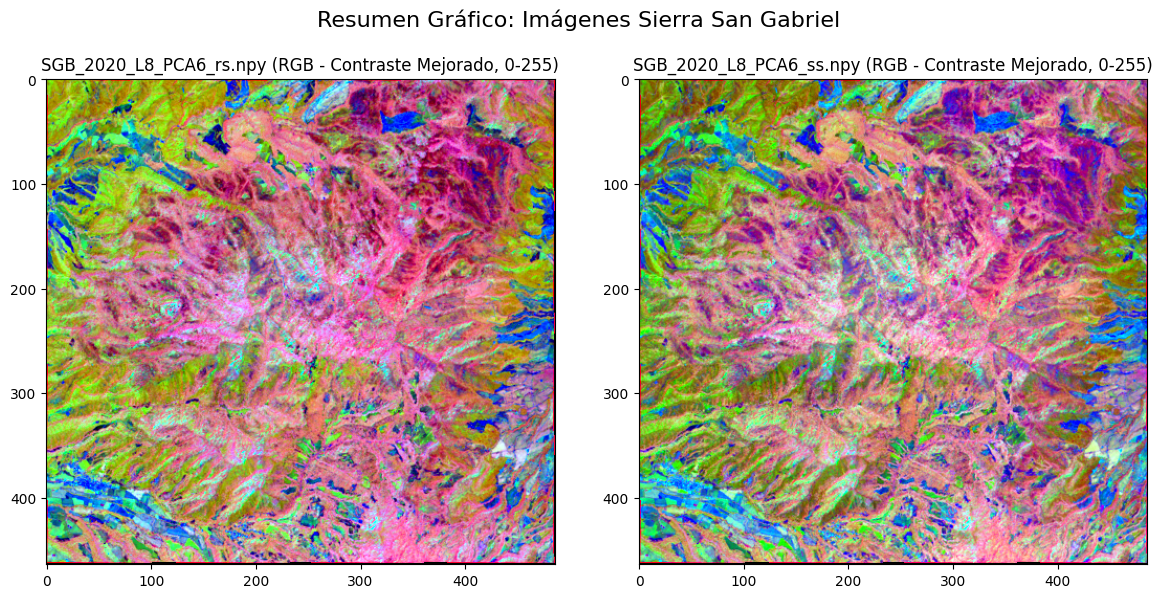

In [3]:
def plot_npy_files_in_grid(file_list, base_path, figure_title, is_imagery_data=False):
    num_files = len(file_list)
    loaded_data = {}
    if num_files == 0:
        print(f"No hay archivos para procesar para {figure_title}.")
        return loaded_data

    cols = min(num_files, 3)
    rows = math.ceil(num_files / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6))
    fig.suptitle(figure_title, fontsize=16)

    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, filename in enumerate(file_list):
        full_path = os.path.join(base_path, filename)
        ax = axes[i]
        print(f"\nProcesando archivo: {filename}")
        try:
            data = np.load(full_path)
            loaded_data[filename] = data # Store the loaded data
            print(f"  Forma: {data.shape}")
            print(f"  Número de elementos: {data.size}")

            im = None
            plot_title = filename

            if data.ndim == 3: # Assuming (bands, height, width)
                num_bands = data.shape[0]
                if is_imagery_data and num_bands >= 3: # Multi-band imagery for RGB
                    rgb_bands = data[0:3, :, :] # Take first 3 channels
                    display_data = np.transpose(rgb_bands, (1, 2, 0)) # Transpose to (H, W, C)

                    normalized_rgb = np.zeros_like(display_data, dtype=np.float32)
                    for k in range(display_data.shape[-1]):
                        channel = display_data[:, :, k]

                        # Apply percentile-based normalization for better contrast and rescale to 0-255
                        # Use np.nanpercentile to ignore NaN values
                        lower_bound = np.nanpercentile(channel, 2)
                        upper_bound = np.nanpercentile(channel, 98)

                        if upper_bound - lower_bound > 0:
                            clipped_channel = np.clip(channel, lower_bound, upper_bound)
                            normalized_rgb[:, :, k] = ((clipped_channel - lower_bound) / (upper_bound - lower_bound)) * 255
                        else:
                            normalized_rgb[:, :, k] = 127 # Mid-gray for 0-255 if no variance

                    # Handle any remaining NaNs in the normalized_rgb by setting them to 0 (black)
                    normalized_rgb[np.isnan(normalized_rgb)] = 0

                    im = ax.imshow(normalized_rgb.astype(np.uint8)) # Display RGB
                    plot_title = f"{filename} (RGB - Contraste Mejorado, 0-255)"
                    # No colorbar for RGB images
                else: # 3D array, but not imagery for RGB, or less than 3 bands
                    # Display first band with viridis colormap
                    # Handle NaNs in the data before displaying
                    display_band = np.nan_to_num(data[0, :, :], nan=0)
                    im = ax.imshow(display_band, cmap='viridis')
                    plot_title = f"{filename} (Escala de Colores Viridis)"
                    fig.colorbar(im, ax=ax, label='Valor del Píxel')

            elif data.ndim == 2: # 2D array (single band)
                # Handle NaNs in the data before displaying
                display_band = np.nan_to_num(data, nan=0)
                im = ax.imshow(display_band, cmap='viridis')
                plot_title = f"{filename} (Escala de Colores Viridis)"
                fig.colorbar(im, ax=ax, label='Valor del Píxel')
            else:
                print(f"  No se puede visualizar el array {data.ndim}D {filename} con imshow. Omitiendo resumen gráfico.")
                ax.set_title(f"No se puede visualizar: {filename}")
                ax.axis('off')
                continue

            ax.set_title(plot_title)
            ax.axis('on')

        except FileNotFoundError:
            print(f"  Error: Archivo no encontrado en {full_path}")
            ax.set_title(f"Archivo no encontrado: {filename}")
            ax.axis('off')
        except Exception as e:
            print(f"  Ocurrió un error al procesar {filename}: {e}")
            ax.set_title(f"Error procesando: {filename}")
            ax.axis('off')

    for j in range(num_files, rows * cols):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return loaded_data # Return the dictionary of loaded data


print("--- Procesando Archivos de Referencia ---")
# Capture the returned dictionary for reference files
reference_data = plot_npy_files_in_grid(reference_file_names, RUTA_DATOS, "Resumen Gráfico: Referencia Sierra San Gabriel")

print("\n--- Procesando Archivos de Imágenes ---")
# Capture the returned dictionary for imagery files
imagery_data = plot_npy_files_in_grid(imagery_file_names, RUTA_DATOS, "Resumen Gráfico: Imágenes Sierra San Gabriel", is_imagery_data=True)

## Preparar datos para clasificación

In [4]:
def feature_transform(source_array):
    # Ensure source_array has at least 3 dimensions for consistency in (bands, height, width)
    # If it's a 2D array, treat it as a single band (1, H, W)
    if source_array.ndim == 2:
        source_array = source_array[np.newaxis, :, :] # Add band dimension
        print(f"  Advertencia: array 2D detectado, transformado a {source_array.shape}")

    # Reshape from (bands, height, width) to (bands, height * width)
    # Then transpose to (height * width, bands)
    # This results in each row representing a pixel and columns representing band values.
    print(source_array.shape)
    table_array = source_array.reshape(source_array.shape[0], -1).T
    print(f"  Forma después de transformar a tabla: {table_array.shape}")
    return table_array

x_features_2020 = feature_transform(imagery_data['SGB_2020_L8_PCA6_rs.npy'])
y_labels_2020 = feature_transform(reference_data['SGB_2020_ref_DW.npy'])

## Consultar un fragmento en la parte interna de conjunto de datos
print(x_features_2020[1000:1020,:])
print(y_labels_2020[1000:1020,:])


(6, 464, 486)
  Forma después de transformar a tabla: (225504, 6)
(1, 464, 486)
  Forma después de transformar a tabla: (225504, 1)
[[-0.31242988  1.3268516  -1.2796625  -0.11474493 -0.14895561 -0.09605685]
 [-0.61182296  1.2187752  -1.5146224   0.10746351 -0.11195119 -0.13501042]
 [ 0.02076983  0.518212   -1.3991389   0.02677326  0.24214862 -0.25930384]
 [ 0.10258943  0.78090966 -0.91796803 -0.99473315 -0.10430768 -0.35060903]
 [-0.06397724  0.84024704 -0.7601937  -1.3000191  -0.1689695  -0.38652858]
 [-0.30630538  1.114381   -1.6278843  -0.53454584  0.05960749 -0.2335725 ]
 [-1.0110378   0.9832257  -1.448327    0.0723223   0.5148067  -0.24902706]
 [-1.0044231   0.17737696 -1.1109369  -0.1103572   0.10975056 -0.23969632]
 [-0.45592973 -0.07615753 -1.3580812  -0.17682809 -0.06521175 -0.43288425]
 [-0.47333494  1.5153538  -1.3727946  -0.47946632  0.00372698 -0.33515155]
 [ 0.01714954  1.457615   -1.3601121  -0.620456    0.00914196 -0.1894228 ]
 [-0.12391666  1.4741082  -1.470151   -0.50


--- Resumen de Frecuencias para y_labels_2020 ---
Valores únicos de categorías en y_labels_2020: [0 1 2 4 5 6 7]
Total de elementos: 225504
Frecuencias Numéricas:
  Categoría 0: 55 ocurrencias (0.02%%)
  Categoría 1: 177914 ocurrencias (78.90%%)
  Categoría 2: 1584 ocurrencias (0.70%%)
  Categoría 4: 16090 ocurrencias (7.14%%)
  Categoría 5: 27791 ocurrencias (12.32%%)
  Categoría 6: 1840 ocurrencias (0.82%%)
  Categoría 7: 230 ocurrencias (0.10%%)


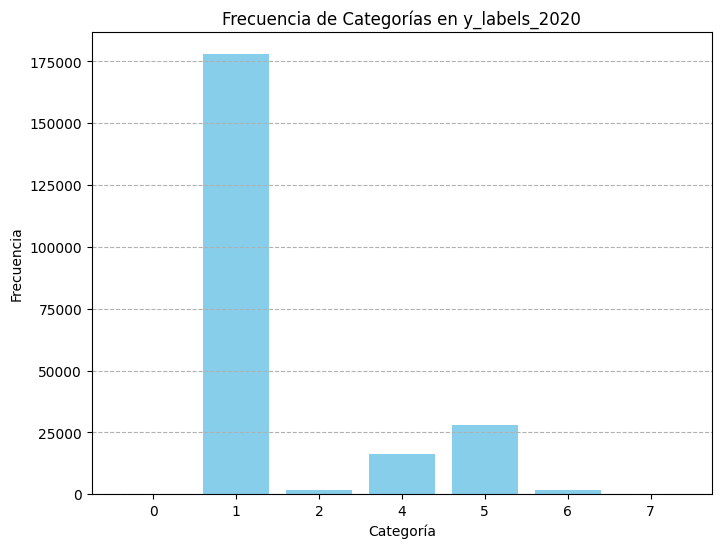

In [5]:
def plot_categorical_frequencies(labels_array, name):
    print(f"\n--- Resumen de Frecuencias para {name} ---")

    # Asegurarse de que el array sea 1D para contar categorías
    flat_labels = labels_array.flatten()

    # Calcular valores únicos y sus conteos
    unique_labels, counts = np.unique(flat_labels, return_counts=True)

    # Resumen Numérico
    print(f"Valores únicos de categorías en {name}: {unique_labels}")
    print(f"Total de elementos: {len(flat_labels)}")
    print("Frecuencias Numéricas:")
    for label, count in zip(unique_labels, counts):
        percentage = (count / len(flat_labels)) * 100
        print(f"  Categoría {label}: {count} ocurrencias ({percentage:.2f}%%)")

    # Resumen Gráfico
    plt.figure(figsize=(8, 6))
    plt.bar(unique_labels.astype(str), counts, color='skyblue')
    plt.title(f'Frecuencia de Categorías en {name}')
    plt.xlabel('Categoría')
    plt.ylabel('Frecuencia')
    plt.xticks(unique_labels.astype(str))
    plt.grid(axis='y', linestyle='--')
    plt.show()


# Procesar y_labels_2020
plot_categorical_frequencies(y_labels_2020, 'y_labels_2020')


--- Resumen de Frecuencias Binarias para y_labels_2020_binary ---
Valores únicos de categorías binarias en y_labels_2020_binary: [0 1]
Total de elementos: 225504
Frecuencias Numéricas:
  Ausencia de Bosque (0): 47590 ocurrencias (21.10%%)
  Presencia de Bosque (1): 177914 ocurrencias (78.90%%)


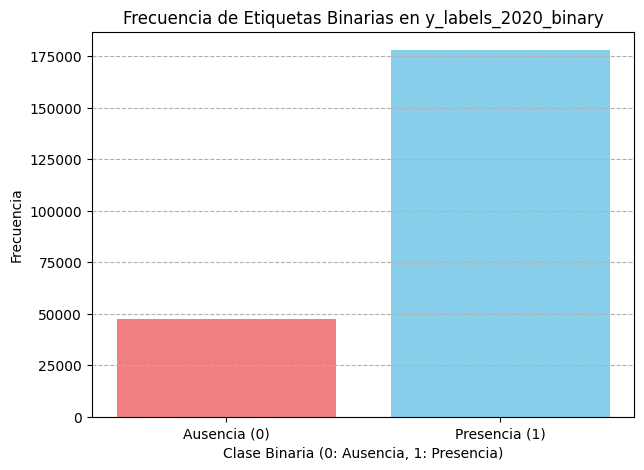

In [6]:
def relabel_to_binary(labels_array, forest_class=1):
    """
    Re-etiqueta un array de categorías a un formato binario.
    `forest_class` se mapea a 1, todas las demás clases a 0.
    """
    # Aplanar el array para asegurar el procesamiento de elementos individuales
    flat_labels = labels_array.flatten()

    # Crear un nuevo array binario
    binary_labels = np.where(flat_labels == forest_class, 1, 0)

    return binary_labels


def plot_binary_label_frequencies(binary_labels_array, name):
    """
    Calcula y grafica las frecuencias de un array de etiquetas binarias (0 o 1).
    """
    print(f"\n--- Resumen de Frecuencias Binarias para {name} ---")

    if binary_labels_array.size == 0:
        print(f"No hay etiquetas para procesar en {name}.")
        return

    unique_labels, counts = np.unique(binary_labels_array, return_counts=True)

    print(f"Valores únicos de categorías binarias en {name}: {unique_labels}")
    print(f"Total de elementos: {len(binary_labels_array)}")
    print("Frecuencias Numéricas:")
    for label, count in zip(unique_labels, counts):
        percentage = (count / len(binary_labels_array)) * 100
        label_name = "Presencia de Bosque (1)" if label == 1 else "Ausencia de Bosque (0)"
        print(f"  {label_name}: {count} ocurrencias ({percentage:.2f}%%)")

    plt.figure(figsize=(7, 5))
    plt.bar([str(l) for l in unique_labels], counts, color=['lightcoral', 'skyblue'])
    plt.title(f'Frecuencia de Etiquetas Binarias en {name}')
    plt.xlabel('Clase Binaria (0: Ausencia, 1: Presencia)')
    plt.ylabel('Frecuencia')
    plt.xticks(['0', '1'], ['Ausencia (0)', 'Presencia (1)'])
    plt.grid(axis='y', linestyle='--')
    plt.show()


# Re-etiquetar y procesar y_labels_2020_SGB
y_labels_2020_binary = relabel_to_binary(y_labels_2020, forest_class=1)
plot_binary_label_frequencies(y_labels_2020_binary, 'y_labels_2020_binary')

In [7]:
xTrain, xTest, yTrain, yTest = train_test_split(x_features_2020, y_labels_2020_binary, test_size=0.4, random_state=2)

print(xTrain.shape)
print(yTrain.shape)

print(xTest.shape)
print(yTest.shape)

print(xTrain)
print(yTrain)

# Reshape the data
xTrain = xTrain.reshape((xTrain.shape[0], 1, xTrain.shape[1]))
xTest = xTest.reshape((xTest.shape[0], 1, xTest.shape[1]))

print(xTrain.shape, xTest.shape)

(135302, 6)
(135302,)
(90202, 6)
(90202,)
[[-0.35070762  0.20564488  0.08598728 -0.71339715 -0.40683955 -0.05138445]
 [ 1.450237    0.82907456  1.8528492   0.5203933   0.20089452 -0.11175008]
 [ 1.3653742   1.7636242   2.0646172   0.10161661 -0.45546937 -0.15105575]
 ...
 [-1.2337519   0.56261665  1.6681223   0.6579273   0.7584091   0.01998671]
 [ 2.1570446  -0.27187806  0.62837374  0.1612279   0.19384438 -0.18545325]
 [ 0.5336122  -1.2689496  -0.12028647 -0.03686155  0.02969682  0.14040619]]
[1 1 1 ... 0 1 1]
(135302, 1, 6) (90202, 1, 6)


In [8]:
import tensorflow as tf
from tensorflow import keras

# Determinar nBands del input xTrain
# xTrain tiene una forma de (samples, 1, nBands_actual)
nBands = xTrain.shape[-1]  # Esto será 1, de (135302, 1, 1)

print(f"Número de bandas de entrada (nBands): {nBands}")

# Define the parameters of the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(1, nBands)), # input_shape será (1, 1), aplanado a 1 característica
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(10, activation='relu'),
    keras.layers.Dense(2, activation='softmax') # Cambiado a 2 clases
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Número de bandas de entrada (nBands): 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372 (1.45 KB)

 Trainable params: 372 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print(f"xTrain original shape: {xTrain.shape}")
print(f"yTrain original shape: {yTrain.shape}")

# 1. Manejar NaNs en xTrain y yTrain
# Encontrar filas con NaNs en yTrain (ahora es 1D y ya binario)
nan_rows_y = np.isnan(yTrain) # yTrain es 1D

# Encontrar filas con NaNs en xTrain (que es 3D: (samples, 1, nBands))
nan_rows_x = np.any(np.isnan(xTrain), axis=(1, 2)) # Check across the last two dimensions

# Combinar ambos para obtener filas a eliminar
rows_to_remove = nan_rows_y | nan_rows_x

xTrain_filtered = xTrain[~rows_to_remove]
yTrain_filtered = yTrain[~rows_to_remove]

print(f"Número de filas eliminadas debido a NaNs: {np.sum(rows_to_remove)}")
print(f"xTrain_filtered shape (después de NaNs): {xTrain_filtered.shape}")
print(f"yTrain_filtered shape (después de NaNs): {yTrain_filtered.shape}")

# yTrain_filtered ya contiene las etiquetas binarias deseadas (0 o 1)
# No es necesario calcular magnitudes de PCA ni percentiles globales, ni excluir la "Clase 1"
yTrain_labels = yTrain_filtered.astype(int) # Asegurarse de que sean enteros para sparse_categorical_crossentropy

print(f"yTrain_labels final shape: {yTrain_labels.shape}")
print(f"Valores únicos en yTrain_labels (0: Ausencia, 1: Presencia): {np.unique(yTrain_labels)}")

# Determinar nBands del input xTrain para el modelo (esto ya se hizo en 6yIEsHR1a_ci, pero lo repetimos para robustez)
nBands = xTrain.shape[-1]  # xTrain tiene una forma de (samples, 1, nBands_actual)
print(f"Número de bandas de entrada (nBands) para el modelo: {nBands}")

# Parámetros de entrenamiento
epochs = 10  # Número de épocas, ajustar según sea necesario
batch_size = 32 # Tamaño del lote, ajustar según sea necesario

print("\nIniciando el entrenamiento del modelo...")
history = model.fit(
    xTrain_filtered,
    yTrain_labels, # Usamos las etiquetas binarias transformadas y filtradas
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2, # Usar una parte de los datos de entrenamiento para validación
    verbose=1
)

print("\nEntrenamiento completado.")


xTrain original shape: (135302, 1, 6)
yTrain original shape: (135302,)
Número de filas eliminadas debido a NaNs: 1240
xTrain_filtered shape (después de NaNs): (134062, 1, 6)
yTrain_filtered shape (después de NaNs): (134062,)
yTrain_labels final shape: (134062,)
Valores únicos en yTrain_labels (0: Ausencia, 1: Presencia): [0 1]
Número de bandas de entrada (nBands) para el modelo: 6

Iniciando el entrenamiento del modelo...
Epoch 1/10
3352/3352 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8797 - loss: 0.2696 - val_accuracy: 0.8876 - val_loss: 0.2515
Epoch 2/10
3352/3352 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8873 - loss: 0.2503 - val_accuracy: 0.8882 - val_loss: 0.2502
Epoch 3/10
3352/3352 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8881 - loss: 0.2487 - val_accuracy: 0.8854 - val_loss: 0.2521
Epoch 4/10
3352/3352 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.8887 - loss: 0.2475 - val_accuracy: 0.8865 - val_loss: 0.2489
Epoch 5/10
3352/3352 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/ste

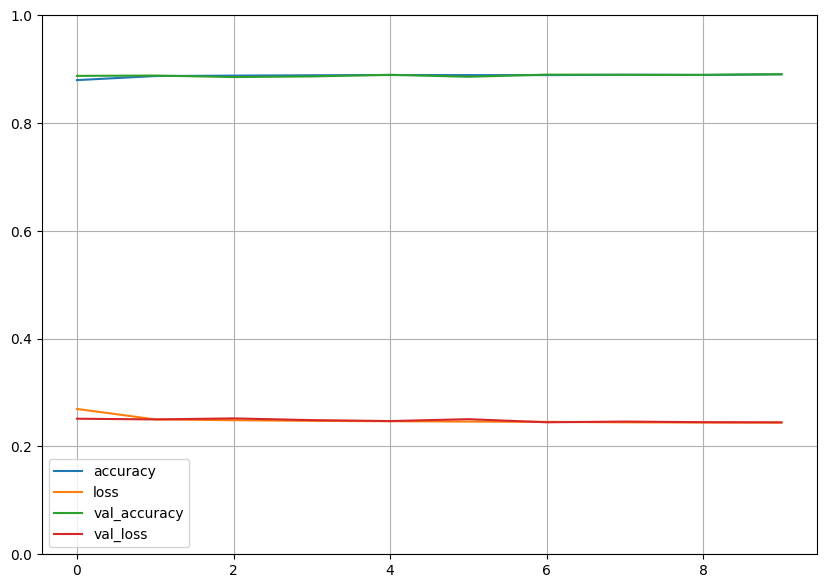

In [11]:

# Opcional: Mostrar resumen del historial de entrenamiento
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1) # Ajustar límites si los datos de precisión/pérdida varían mucho
plt.show()

Realizando predicciones con x_features_2020 completos...
Forma de x_features_2020 antes de la predicción: (225504, 1, 6)
7047/7047 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Forma de las clases predichas: (225504,)
Forma del mapa de predicción reestructurado: (464, 486)


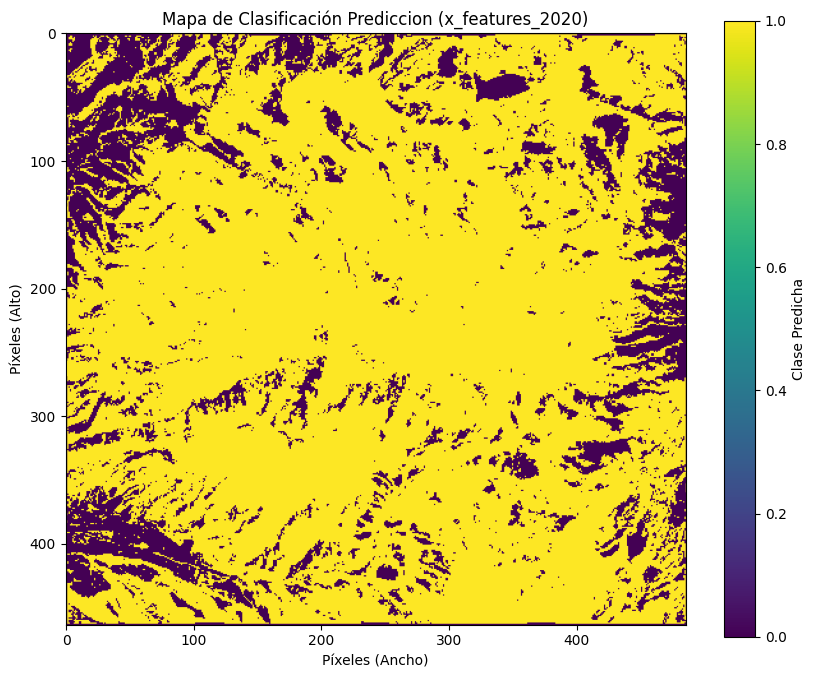

In [12]:
print("Realizando predicciones con x_features_2020 completos...")

# 1. Reshape x_features_2020 para que coincida con la entrada del modelo
# El modelo espera (samples, 1, nBands), donde nBands es 1.
# x_features_2020 tiene forma (225504, 1), necesitamos (225504, 1, 1)
x_features_2020_reshaped = x_features_2020.reshape((x_features_2020.shape[0], 1, x_features_2020.shape[1]))

print(f"Forma de x_features_2020 antes de la predicción: {x_features_2020_reshaped.shape}")

# 2. Realizar predicciones
predictions_2020 = model.predict(x_features_2020_reshaped)

# Las predicciones son probabilidades, obtener la clase predicha (índice con la probabilidad más alta)
predicted_classes_2020 = np.argmax(predictions_2020, axis=1)

print(f"Forma de las clases predichas: {predicted_classes_2020.shape}")

# 3. Regresar el conjunto a su forma original de array (alto, ancho)
# Obtener las dimensiones originales del array 2D.
# SGB_2020_ref_DW.npy tenía forma (1, 464, 486). La 'altura' y 'ancho' son 464 y 486.
original_height = reference_data['SGB_2020_ref_DW.npy'].shape[1]
original_width = reference_data['SGB_2020_ref_DW.npy'].shape[2]

predicted_map_2020 = predicted_classes_2020.reshape(original_height, original_width)

print(f"Forma del mapa de predicción reestructurado: {predicted_map_2020.shape}")

# 4. Presentar visualmente el resultado
plt.figure(figsize=(10, 8))
im_2020 = plt.imshow(predicted_map_2020, cmap='viridis') # Puedes cambiar el colormap
plt.colorbar(im_2020, label='Clase Predicha')
plt.title('Mapa de Clasificación Prediccion (x_features_2020)')
plt.xlabel('Píxeles (Ancho)')
plt.ylabel('Píxeles (Alto)')
plt.show()


In [14]:
# --- Procesar el conjunto de prueba (xTest, yTest) para evaluación ---

print(f"xTest original shape: {xTest.shape}")
print(f"yTest original shape: {yTest.shape}")

# 1. Manejar NaNs en xTest y yTest de la misma manera que en el entrenamiento
nan_rows_y_test = np.isnan(yTest) # yTest es 1D
nan_rows_x_test = np.any(np.isnan(xTest), axis=(1, 2)) # Check across the last two dimensions
rows_to_remove_test = nan_rows_y_test | nan_rows_x_test

xTest_filtered = xTest[~rows_to_remove_test]
yTest_filtered = yTest[~rows_to_remove_test]

print(f"Número de filas eliminadas de xTest/yTest debido a NaNs: {np.sum(rows_to_remove_test)}")
print(f"Forma de xTest_filtered (después de NaNs): {xTest_filtered.shape}")
print(f"Forma de yTest_filtered (después de NaNs): {yTest_filtered.shape}")

# yTest_filtered ya contiene las etiquetas binarias deseadas (0 o 1)
yTest_labels = yTest_filtered.astype(int) # Asegurarse de que sean enteros

print(f"Forma de yTest_labels (etiquetas verdaderas): {yTest_labels.shape}")
print(f"Valores únicos en yTest_labels (0: Ausencia, 1: Presencia): {np.unique(yTest_labels)}")

# 2. Realizar predicciones con el modelo usando xTest_filtered
predictions_on_xTest = model.predict(xTest_filtered)

# Convertir las probabilidades predichas a clases (0, 1)
yTest_predicted_classes = np.argmax(predictions_on_xTest, axis=1)

print(f"Forma de yTest_predicted_classes (etiquetas predichas): {yTest_predicted_classes.shape}")
print(f"Valores únicos en yTest_predicted_classes: {np.unique(yTest_predicted_classes)}")

## Calcular métricas de clasificación binaria (Clase 0 y Clase 1)
cMatrix = confusion_matrix(yTest_labels, yTest_predicted_classes)
accuracy = accuracy_score(yTest_labels, yTest_predicted_classes)
kappa = cohen_kappa_score(yTest_labels, yTest_predicted_classes)

# Usar zero_division=0 para manejar casos donde una clase no esté presente en las etiquetas verdaderas o predichas
pScore = precision_score(yTest_labels, yTest_predicted_classes, average=None, zero_division=0)
rScore = recall_score(yTest_labels, yTest_predicted_classes, average=None, zero_division=0)
f1Score = f1_score(yTest_labels, yTest_predicted_classes, average=None, zero_division=0)

print("\nConfusion matrix:\n", cMatrix)
print("\nExactitud (accuracy): %.3f" % accuracy)
print("\nKappa de Cohen: %.3f" % kappa)
print("\nClase 0 (Ausencia de Bosque). Selectividad (precision): %.3f, especificidad (recall): %.3f, f1: %.3f" % (pScore[0], rScore[0], f1Score[0]))
print("Clase 1 (Presencia de Bosque). Selectividad (precision): %.3f, especificidad (recall): %.3f, f1: %.3f" % (pScore[1], rScore[1], f1Score[1]))



xTest original shape: (90202, 1, 6)
yTest original shape: (90202,)
Número de filas eliminadas de xTest/yTest debido a NaNs: 788
Forma de xTest_filtered (después de NaNs): (89414, 1, 6)
Forma de yTest_filtered (después de NaNs): (89414,)
Forma de yTest_labels (etiquetas verdaderas): (89414,)
Valores únicos en yTest_labels (0: Ausencia, 1: Presencia): [0 1]
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Forma de yTest_predicted_classes (etiquetas predichas): (89414,)
Valores únicos en yTest_predicted_classes: [0 1]

Confusion matrix:
 [[12950  5824]
 [ 3997 66643]]

Exactitud (accuracy): 0.890

Kappa de Cohen: 0.657

Clase 0 (Ausencia de Bosque). Selectividad (precision): 0.764, especificidad (recall): 0.690, f1: 0.725
Clase 1 (Presencia de Bosque). Selectividad (precision): 0.920, especificidad (recall): 0.943, f1: 0.931
